# Select data day

In [ ]:
import pandas as pd
from decimal import Decimal
import matplotlib.pyplot as plt
import numpy as np
import math 
from typing import List, Union, Optional
from astropy.time import Time
import missingno as msno
import statsmodels.api as sm
import allantools as at
from scipy import stats

## Only ErYb data is read in as Decimal
def open_ErYb_data(data_path):
    key2read = ["MJD", "timer", "SDR:frep_ErYb", "fo_ErYb", "fb_Si_ErYb", "fb_Yb_ErYb", "fb_Al_ErYb"] 
    types = {key: str for key in key2read}
    types["MJD"] = float
 
    data = pd.read_csv(data_path, header=1, delimiter="\t", dtype=types, engine="python")
 
    for k in key2read:
        data[k] = data[k].apply(Decimal)
 
    data.index = range(len(data))
 
    return data[list(types.keys())]

## Shift data and maser corrections are read in as floats 
def open_shiftfile_Al(datapath):
    data = pd.read_csv(datapath, header=30, delimiter="\t", dtype={1: str}, engine="python")
 
    data.columns = ["MJD", "shift", "IS_GOOD"]
 
    data["IS_GOOD"] = data["IS_GOOD"].apply(lambda x: x == 1.0)
 
    data.loc[~data["IS_GOOD"], "shift"] = np.nan
 
    data["shift"] = data["shift"].apply(float) ##should this be Decimal instead?
 
    return data

def open_shiftfile_Sr(datapath): ##Note: assuming (unverified) that for days_irregular all Sr .dat files have this format.... 
    data = pd.read_csv(datapath, header=24, delimiter="\t", dtype={1: str}, engine="python")

    data.columns = ["MJD", "shift", "IS_GOOD"]
 
    data["IS_GOOD"] = data["IS_GOOD"].apply(lambda x: x == 1.0)
 
    data.loc[~data["IS_GOOD"], "shift"] = np.nan
 
    data["shift"] = data["shift"].apply(float) ##should this be Decimal instead?
 
    return data
 
def open_shiftfile_Yb(datapath):
    data = pd.read_csv(datapath, header=8, delimiter=r"\t",  dtype={1: str}, engine="python")
 
    data.columns = ["MJD", "shift", "IS_GOOD"]
 
    data["IS_GOOD"] = data["IS_GOOD"].apply(lambda x: x == 1.0)
 
    data.loc[~data["IS_GOOD"], "shift"] = np.nan
 
    data["shift"] = data["shift"].apply(float) ##should this be Decimal instead?
 
    return data
 
def open_maser_correction(datapath):
    data = pd.read_csv(datapath, header=1, delimiter=",", dtype={1: str}, engine="python")
 
    data.columns = ["date", "maser_offset"]
 
    data["date"] = data["date"].apply(str)#.str.split("-").str.join("")
    data["maser_offset"] = data["maser_offset"].apply(float) ##should this be Decimal instead?
 
    return data

In [ ]:
path = "/Users/smt3/Documents/GitHub/2025 clock comparison data/"
days = [20250204, 20250227, 20250304, 20250307, 20250318]
days = list(map(str, days))
day_index = 4 ##set anywhere from 0:4

days_irregular = [20250206, 20250228, 20250306, 20250313, 20250320, 20250321]
days_irregular = list(map(str, days_irregular))
day_irregular_index = None ##set to None if analyzing days, set to 0:5 if analyzing days_irregular

## to keep track of the data day 
if day_irregular_index != None:
    what_is_the_day = days_irregular[day_irregular_index]
else:
    what_is_the_day = days[day_index]

## For days_irregular, read in Sr data with the following 
if day_irregular_index != None:
    if days_irregular[day_irregular_index] == "20250206":
        shift_data_Sr = pd.concat(
            [
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock0.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock2.dat"),
            ],
            ignore_index=True,
        )
    elif days_irregular[day_irregular_index] == "20250228":
        shift_data_Sr = open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock1.dat")
    elif days_irregular[day_irregular_index] == "20250306":
        shift_data_Sr = open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock2.dat")
    elif days_irregular[day_irregular_index] == "20250313":
        shift_data_Sr = pd.concat(
            [
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock0.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock1.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock2.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock3.dat"),
            ],
            ignore_index=True,
        )
    elif days_irregular[day_irregular_index] == "20250320":
        shift_data_Sr = pd.concat(
            [
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock0.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock2.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock4.dat"),
            ],
            ignore_index=True,
        )
    elif days_irregular[day_irregular_index] == "20250321":
        shift_data_Sr = pd.concat(
            [
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock0.dat"),
                open_shiftfile_Sr(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_clock_lock1.dat"),
            ],
            ignore_index=True,
        )
else: 
    shift_data_Sr = open_shiftfile_Sr(path + days[day_index] + "/" + days[day_index] + "_clock_lock0.dat")

# Read in data and corrections

In [127]:
maser_corrections = open_maser_correction(path + "daily maser offsets.csv")

if day_irregular_index != None:
    data_ErYb = open_ErYb_data(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_Deglitched_ErYb_only.dat") 
    shift_data_Al = open_shiftfile_Al(path + days_irregular[day_irregular_index] + "/" + days_irregular[day_irregular_index] + "_Alp_Freq_Shifts_ErYb.dat")
    shift_data_Yb = open_shiftfile_Yb(path + days_irregular[day_irregular_index] + "/YbI_1_rerun.txt")
else:
    data_ErYb = open_ErYb_data(path + days[day_index] + "/" + days[day_index] + "_Deglitched_ErYb_only.dat") 
    shift_data_Al = open_shiftfile_Al(path + days[day_index] + "/" + days[day_index] + "_Alp_Freq_Shifts_ErYb.dat")
    shift_data_Yb = open_shiftfile_Yb(path + days[day_index] + "/YbI_1_rerun.txt")


def compute_nuAl_ErYb(data):
    data["nuAl"] = -Decimal("105e6") + Decimal("560444") * (Decimal("1e9") + data["SDR:frep_ErYb"]) / Decimal(2) - data["fb_Al_ErYb"]
    data["nuAl"] = Decimal(4) * data["nuAl"]   

def compute_nuSr_ErYb(data):
    data["nuSi"] = -Decimal("105e6") + Decimal("388752") * (Decimal("1e9") + data["SDR:frep_ErYb"]) / Decimal(2) - Decimal("100e6")
    data["nuSr"] = (Decimal("1716882") / Decimal("777577")) * (data["nuSi"] - Decimal("216e6"))

def compute_nuYb_ErYb(data):
    data["nuYb"] = -Decimal("105e6") + Decimal("518237") * (Decimal("1e9") + data["SDR:frep_ErYb"]) / Decimal(2) - data["fb_Yb_ErYb"]
    data["nuYb"] = Decimal(2) * data["nuYb"] 

compute_nuAl_ErYb(data_ErYb)
compute_nuSr_ErYb(data_ErYb)
compute_nuYb_ErYb(data_ErYb) 

YbSrRatio2020 = Decimal("1.2075070393433378482") 
AlYbRatio2020 = Decimal("2.162887127516663703")
AlSrRatio2020 = Decimal("2.611701431781463025")
 
if day_irregular_index != None:
    correction_condition = days_irregular[day_irregular_index] == maser_corrections["date"]
else: 
    correction_condition = days[day_index] == maser_corrections["date"]
masercorrection = maser_corrections[correction_condition]["maser_offset"].apply(Decimal) # could remove .apply(Decimal) if import data as Decimal above 

GR_shift_Al = Decimal("-8.114e-16") 
GR_shift_Yb = Decimal("-8.109e-16")
GR_shift_Sr = Decimal("10.660e-16")
GR_shift_sea_level = Decimal("-1798.501e-16")

total_correction_Yb = Decimal("1") + GR_shift_Yb + GR_shift_sea_level + masercorrection
total_correction_Sr = Decimal("1") + GR_shift_Sr + GR_shift_sea_level + masercorrection
total_correction_Al = Decimal("1") + GR_shift_Al + GR_shift_sea_level + masercorrection

# Use only good and non-NA data

In [ ]:
## shift data are read in as floats 
al_cond = ~shift_data_Al['shift'].isna() 
Al_non_na = shift_data_Al[al_cond]
good_condition_al = Al_non_na["IS_GOOD"] == 1
shift_data_Al_good = Al_non_na[good_condition_al].reset_index(drop=True, inplace = False)
Al_good = pd.Series(shift_data_Al_good['MJD'])

sr_cond = ~shift_data_Sr['shift'].isna()
Sr_non_na = shift_data_Sr[sr_cond]
good_condition_sr = Sr_non_na["IS_GOOD"] == 1
shift_data_Sr_good = Sr_non_na[good_condition_sr].reset_index(drop=True, inplace = False)
Sr_good = pd.Series(shift_data_Sr_good['MJD'])

yb_cond = ~shift_data_Yb['shift'].isna()
Yb_non_na = shift_data_Yb[yb_cond]
good_condition_yb = Yb_non_na["IS_GOOD"] == 1
shift_data_Yb_good = Yb_non_na[good_condition_yb].reset_index(drop=True, inplace = False)
Yb_good = pd.Series(shift_data_Yb_good['MJD']) 

In [ ]:
## Define a function to catch all types of "missing" since comb columns are Decimals
def is_really_missing(x):
    if x is None:
        return True
    if isinstance(x, float) and pd.isna(x):
        return True
    if isinstance(x, Decimal) and x.is_nan():
        return True
    return False

# summary_decimal = data_ErYb.applymap(is_really_missing).sum()
# print(summary_decimal)
# summary = data_ErYb.isna().sum()
# print(summary)

comb_full = data_ErYb[data_ErYb['nuAl'].notna() & data_ErYb['nuSr'].notna() & data_ErYb['nuYb'].notna()]
# summary2 = comb_full.isna().sum()
# print(summary2)
# print("Comb nuYb data type after removing nans: ", type(comb_full["nuYb"].iloc[10]))

shift data type for Yb:  <class 'numpy.float64'>
MJD data type for Yb:  <class 'numpy.float64'>
comb data type for nuYb:  <class 'decimal.Decimal'>
MJD data type for comb nuYb:  <class 'decimal.Decimal'>
Al sampling rate 1.2 s
Al min, first quartile, median, thrid quartile, max:
 [9.93599393e-01 9.93600022e-01 1.00224009e+00 1.00224009e+00
 2.96099712e+03]
Sr sampling rate 8.8 s
Sr min, first quartile, median, thrid quartile, max:
 [  8.63704327   8.65112409   8.65424357   8.65750308 175.26027197]
Yb sampling rate 1.0 s
Yb min, first quartile, median, thrid quartile, max:
 [0.99014374 1.00915201 1.01001577 1.01087952 1.03075218]
ErYb sampling rate 1.1 s
ErYb min, first quartile, median, thrid quartile, max:
 [1.03679972 1.03679972 1.03680035 1.03680035 3.19679982]


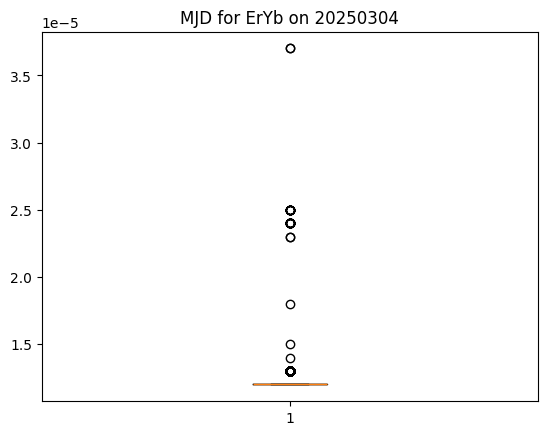

In [ ]:
# ##Check data types 
# print("shift data type for Yb: ", type(shift_data_Yb_good["MJD"].iloc[10]))
# print("MJD data type for Yb: ", type(shift_data_Yb_good["shift"].iloc[10]))

# print("comb data type for nuYb: ", type(comb_full["MJD"].iloc[10]))
# print("MJD data type for comb nuYb: ", type(comb_full["nuYb"].iloc[10]))

# ##Sampling rates 
# print("Al sampling rate", '{:0.2}'.format( np.mean(np.diff(shift_data_Al_good["MJD"]))*24*3600 ), "s" )
# print("Al min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(shift_data_Al_good["MJD"]), [0, 25, 50, 75, 100])*24*3600)

# print("Sr sampling rate", '{:0.2}'.format( np.mean(np.diff(shift_data_Sr_good["MJD"]))*24*3600 ), "s" )
# print("Sr min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(shift_data_Sr_good["MJD"]), [0, 25, 50, 75, 100])*24*3600)

# print("Yb sampling rate", '{:0.2}'.format( np.mean(np.diff(shift_data_Yb_good["MJD"]))*24*3600 ), "s" )
# print("Yb min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(shift_data_Yb_good["MJD"]), [0, 25, 50, 75, 100])*24*3600)

# print("ErYb sampling rate", '{:0.2}'.format( np.mean(np.diff(comb_full["MJD"]))*24*3600 ), "s" )
# print("ErYb min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(comb_full["MJD"].astype(float)), [0, 25, 50, 75, 100])*24*3600)

# float_comb1 = [float(y) for y in np.diff(comb_full["MJD"])]
# plt.boxplot(float_comb1)
# plt.title(f"MJD for ErYb on {what_is_the_day}")
# plt.show()

# Create constant sampling version of decimal comb data

In [ ]:
comb_datetime = comb_full.copy()
print("Data type of comb_datetime nuAl: ", type(comb_datetime["nuAl"].iloc[4]))
comb_datetime_array = Time(comb_datetime['MJD'], format = 'mjd').to_datetime()
comb_datetime.index = pd.DatetimeIndex(comb_datetime_array)

print("ErYb min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(comb_datetime["MJD"].astype(float)), [0, 25, 50, 75, 100])*24*3600)
# print(type(comb_datetime.index))
mode_ErYb = stats.mode(np.diff(comb_datetime.index), keepdims=True)

## Generate new, empty constant-frequency grid
const_samp_rate = mode_ErYb.mode[0]
resample_freq = pd.to_timedelta(const_samp_rate, unit='ns')
comb_constant = comb_datetime.resample(resample_freq).asfreq().index 

## Identify strictly the new timestamps that don't already exist in your data
new_timestamps = comb_constant.difference(comb_datetime.index)

## Fill the empty dataframe with a STRING to block float coercion
empty_df = pd.DataFrame(
    "GAP", 
    index=new_timestamps, 
    columns=comb_datetime.columns, 
    dtype='object'
)

## Concatenate and sort - Because it's mixing Decimals and Strings (for gaps), Pandas MUST keep it as an object array
comb_combined = pd.concat([comb_datetime, empty_df]).sort_index()

#print(type(comb_combined["nuAl"].iloc[4]))

Data type of comb_datetime nuAl:  <class 'decimal.Decimal'>
ErYb min, first quartile, median, thrid quartile, max:
 [1.03679972 1.03679972 1.03680035 1.03680035 3.19679982]


In [ ]:
## Function to interpolate over decimals (values) and strings (missing data)  
def interpolate_decimals_pure(df, columns):
    """
    Interpolates missing 'GAP' values using strictly pure Python/Decimal math
    to absolutely prevent Pandas float64 coercion.
    """
    df_out = df.copy()
    
    # Extract index as raw integer nanoseconds for perfect precision math
    time_ns = df_out.index.astype('int64').values
    
    for col in columns:
        # Extract the column into a pure Python list to escape Pandas
        vals = df_out[col].tolist()
        
        for i in range(len(vals)):
            if vals[i] == "GAP":
                # Find the previous valid Decimal
                prev_idx = i - 1
                while prev_idx >= 0 and vals[prev_idx] == "GAP":
                    prev_idx -= 1
                
                # Find the next valid Decimal
                next_idx = i + 1
                while next_idx < len(vals) and vals[next_idx] == "GAP":
                    next_idx += 1
                    
                # If the gap is bounded on both sides, interpolate!
                if prev_idx >= 0 and next_idx < len(vals):
                    v_prev = vals[prev_idx]
                    v_next = vals[next_idx]
                    
                    t_target = Decimal(int(time_ns[i]))
                    t_prev = Decimal(int(time_ns[prev_idx]))
                    t_next = Decimal(int(time_ns[next_idx]))
                    
                    # Decimal interpolation math
                    time_ratio = (t_target - t_prev) / (t_next - t_prev)
                    vals[i] = v_prev + (v_next - v_prev) * time_ratio
                else:
                    # If the GAP is at the very beginning or end of the dataset,
                    # we can't interpolate. We leave it as "GAP" or replace with None.
                    pass 
        
        # Safely assign the list of Decimals back to the DataFrame
        df_out[col] = vals
        
    return df_out

## Apply the pure-Python decimal interpolation
cols_to_interpolate = ["MJD", "nuAl", "nuSr", "nuYb"]
comb_combined_interpolated = interpolate_decimals_pure(comb_combined, cols_to_interpolate)
comb_combined_interpolated = comb_combined_interpolated[cols_to_interpolate]
#print(comb_combined_interpolated.head())
#print("comb_combined_interpolated MJD quartiles:\n", np.percentile(np.diff(comb_combined_interpolated["MJD"].astype(float)), [0, 25, 50, 75, 100])*24*3600)

## Slice the combined DataFrame down to ONLY the new constant-frequency grid
comb_final_constant = comb_combined_interpolated.reindex(comb_constant)

## Any unbounded edge cases left as "GAP" can safely be turned to None if needed
comb_final_constant = comb_final_constant.replace("GAP", None)
#print(comb_final_constant.head())

## Extract all but the first row which contains None 
comb_final_constant = comb_final_constant.iloc[1:] 
# print(comb_final_constant.head())
print("comb_final_constant MJD quartiles:\n", np.percentile(np.diff(comb_final_constant["MJD"].astype(float)), [0, 25, 50, 75, 100])*24*3600)

# print(type(comb_final_constant["nuAl"].iloc[10]))
# print(comb_final_constant.index)

comb_final_constant MJD quartiles:
 [1.03679909 1.03679972 1.03679972 1.03680035 1.03680035]


# Overlapping window of observations

In [133]:
len_comb = len(comb_final_constant['MJD']) 
len_Al = len(shift_data_Al_good['shift'])        
len_Sr = len(shift_data_Sr_good['shift'])        
len_Yb = len(shift_data_Yb_good['shift'])

print("Comb start and end MJD: [", '{:0.11}'.format(comb_final_constant['MJD'].iloc[0]), ', ', '{:0.11}'.format(comb_final_constant['MJD'].iloc[len_comb-1]), ']')
print("Al good shift start and end MJD: [", shift_data_Al_good['MJD'].iloc[0], ', ', shift_data_Al_good['MJD'].iloc[len_Al-1], ']')
print("Sr good shift start and end MJD: [", shift_data_Sr_good['MJD'].iloc[0], ', ', shift_data_Sr_good['MJD'].iloc[len_Sr-1], ']')
print("Yb good shift start and end MJD: [", shift_data_Yb_good['MJD'].iloc[0], ', ', shift_data_Yb_good['MJD'].iloc[len_Yb-1], ']')

## Restrict exploration to Al+/Yb ratio for now while investigating AVAR differences for interpolation strategies
starts = [comb_final_constant['MJD'].iloc[1], shift_data_Al_good['MJD'].iloc[0], shift_data_Yb_good['MJD'].iloc[0]] 
ends = [comb_final_constant['MJD'].iloc[len_comb-1], shift_data_Al_good['MJD'].iloc[len_Al-1], shift_data_Yb_good['MJD'].iloc[len_Yb-1]] 

last_start_time = max(starts)
first_end_time = min(ends)

print("Last start time: ", last_start_time)
print("First end time: ", first_end_time)

Comb start and end MJD: [ 60738.764124 ,  60739.025676 ]
Al good shift start and end MJD: [ 60738.8206019 ,  60739.0171412 ]
Sr good shift start and end MJD: [ 60738.80439413155 ,  60739.01857040927 ]
Yb good shift start and end MJD: [ 60738.74950488 ,  60739.01545343 ]
Last start time:  60738.8206019
First end time:  60739.01545343


In [134]:
def lb_extract(target, data):
    inx = 0 
    while inx < len(data):
        val = data.iloc[inx]
        
        #Skip over missing values without crashing
        if val is None or pd.isna(val) or val == "GAP":
            inx += 1
            continue
            
        # If it's a valid number, do the comparison
        if val >= target:
            return inx
            
        # If it's too small, move to the next row
        inx += 1
        
    # If we check every row and find nothing, safely return None
    return None
            
def ub_extract(target, data):
    inx = 1
    # Loop runs as long as we haven't checked beyond the first row
    while inx <= len(data):
        # We use -inx to count backwards from the end
        val = data.iloc[len(data) - inx]
        
        # Skip over missing values
        if val is None or pd.isna(val) or val == "GAP":
            inx += 1
            continue
            
        # Check the condition
        if val <= target:
            return len(data) - inx
            
        # Keep moving backwards
        inx += 1
        
    return None

#print(comb_final_constant.head())
comb_start = ub_extract(target = last_start_time, data = comb_final_constant['MJD'])  
comb_end = lb_extract(target = first_end_time, data = comb_final_constant['MJD']) 
## The next two lines are necessary b/c comb_final_constant is already indexed by datetime and "cannot do slice indexing on DatetimeIndex with indexers of type int"
comb_start_datetime = Time(comb_final_constant['MJD'].iloc[comb_start], format='mjd').to_datetime()
comb_end_datetime = Time(comb_final_constant['MJD'].iloc[comb_end], format='mjd').to_datetime()
comb_chunk = comb_final_constant.loc[comb_start_datetime:comb_end_datetime].copy()
#print(comb_chunk.head())

# print(shift_data_Al_good.tail())
# print(al_start, al_end)
Al_start = ub_extract(target = last_start_time, data = shift_data_Al_good["MJD"])
Al_end = lb_extract(target = first_end_time, data = shift_data_Al_good["MJD"])  
Al_chunk = shift_data_Al_good.loc[Al_start:Al_end].copy()
# print(al_chunk.tail())

Sr_start = ub_extract(target = last_start_time, data = shift_data_Sr_good["MJD"])
Sr_end = lb_extract(target = first_end_time, data = shift_data_Sr_good["MJD"])  
Sr_chunk = shift_data_Sr_good.loc[Sr_start:Sr_end].copy()

Yb_start = ub_extract(target = last_start_time, data = shift_data_Yb_good["MJD"])
Yb_end = lb_extract(target = first_end_time, data = shift_data_Yb_good["MJD"])  
Yb_chunk = shift_data_Yb_good.loc[Yb_start:Yb_end].copy()

## Reindex shift data with datetime comb index 

In [ ]:
## Create datetime index for shift data
shift_data_Al_datetime = Al_chunk.copy()
shift_data_Al_datetime['datetime'] = Time(shift_data_Al_datetime['MJD'], format = 'mjd').to_datetime()
shift_data_Al_datetime = shift_data_Al_datetime.set_index('datetime')

shift_data_Sr_datetime = Sr_chunk.copy()
shift_data_Sr_datetime['datetime'] = Time(shift_data_Sr_datetime['MJD'], format = 'mjd').to_datetime()
shift_data_Sr_datetime = shift_data_Sr_datetime.set_index('datetime')

shift_data_Yb_datetime = Yb_chunk.copy()
shift_data_Yb_datetime['datetime'] = Time(shift_data_Yb_datetime['MJD'], format = 'mjd').to_datetime()
shift_data_Yb_datetime = shift_data_Yb_datetime.set_index('datetime')

## Reindex to match comb constant sampling rate 
interp_times_Al = comb_chunk.index.difference(shift_data_Al_datetime.index)
long_Al_index = shift_data_Al_datetime.index.union(interp_times_Al).sort_values() 
Al_chunk_expanded = shift_data_Al_datetime.reindex(long_Al_index)

interp_times_Sr = comb_chunk.index.difference(shift_data_Sr_datetime.index)
long_Sr_index = shift_data_Sr_datetime.index.union(interp_times_Sr).sort_values() 
Sr_chunk_expanded = shift_data_Sr_datetime.reindex(long_Sr_index)

interp_times_Yb = comb_chunk.index.difference(shift_data_Yb_datetime.index)
long_Yb_index = shift_data_Yb_datetime.index.union(interp_times_Yb).sort_values() 
Yb_chunk_expanded = shift_data_Yb_datetime.reindex(long_Yb_index)

##Note: after interpolation, will need to keep only the shift values on the constant sampling index (i.e. comb_chunk.index)

In [ ]:
##---Check sampling rates before shift interpolation 
# print("comb MJD quartiles:\n", np.percentile(np.diff(comb_chunk["MJD"].astype(float)), [0, 25, 50, 75, 100]))
# print("Yb MJD quartiles:\n", np.percentile(np.diff(Yb_chunk_expanded["MJD"].astype(float)), [0, 25, 50, 75, 100]))

# print(comb_chunk.index.to_series().diff().quantile([0.25, 0.5, 0.75, 0.9, 0.95]))
# print(Al_chunk_expanded.index.to_series().diff().quantile([0.25, 0.5, 0.75, 0.9, 0.95]))
# print(Sr_chunk_expanded.index.to_series().diff().quantile([0.25, 0.5, 0.75, 0.9, 0.95]))
# print(Yb_chunk_expanded.index.to_series().diff().quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

# print("nuAl, nuSr, and nuYb start and end MJD: [", '{:0.11}'.format(comb_chunk["MJD"].iloc[0]), ', ', '{:0.11}'.format(comb_chunk["MJD"].iloc[len(comb_chunk["MJD"])-1]), ']')
# print("Al good shift start and end MJD: [", Al_chunk_expanded['MJD'].iloc[0], ', ', Al_chunk_expanded['MJD'].iloc[len(Al_chunk_expanded['MJD'])-1], ']')
# print("Sr good shift start and end MJD: [", Sr_chunk_expanded['MJD'].iloc[0], ', ', Sr_chunk_expanded['MJD'].iloc[len(Sr_chunk_expanded['MJD'])-1], ']')
# print("Yb good shift start and end MJD: [", Yb_chunk_expanded['MJD'].iloc[0], ', ', Yb_chunk_expanded['MJD'].iloc[len(Yb_chunk_expanded['MJD'])-1], ']')

comb MJD quartiles:
 [1.19999895e-05 1.19999968e-05 1.19999968e-05 1.20000041e-05
 1.20000041e-05]
Yb MJD quartiles:
 [nan nan nan nan nan]
0.25   0 days 00:00:01.036800
0.50   0 days 00:00:01.036800
0.75   0 days 00:00:01.036800
0.90   0 days 00:00:01.036800
0.95   0 days 00:00:01.036800
dtype: timedelta64[ns]
0.25   0 days 00:00:00.285120
0.50   0 days 00:00:00.561600
0.75   0 days 00:00:00.846720
0.90   0 days 00:00:01.002240
0.95   0 days 00:00:01.036800
dtype: timedelta64[ns]
0.25   0 days 00:00:01.036800
0.50   0 days 00:00:01.036800
0.75   0 days 00:00:01.036800
0.90   0 days 00:00:01.036800
0.95   0 days 00:00:01.036800
dtype: timedelta64[ns]
0.25   0 days 00:00:00.256608
0.50   0 days 00:00:00.511488
0.75   0 days 00:00:00.767664
0.90   0 days 00:00:00.921024
0.95   0 days 00:00:00.972000
dtype: timedelta64[ns]
nuAl, nuSr, and nuYb start and end MJD: [ 60738.820596 ,  60739.015464 ]
Al good shift start and end MJD: [ nan ,  nan ]
Sr good shift start and end MJD: [ 60738.820520

# Interpolation 

In [ ]:
## Function to set kalman smoothing interpolation limit
def detect_long_missing(data, max_len):  
    mask = data.isna()
    long_gaps = pd.Series(False, index=data.index)

    start = None
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            if i - start > max_len:
                long_gaps[start:i] = True
            start = None
    if start is not None and len(data) - start > max_len:
        long_gaps[start:] = True

    return long_gaps

## Create a dictionary to store all six interpolation results 
interp_Al_results = {} 
interp_Sr_results = {} 
interp_Yb_results = {} 
interp_methods = ['time', 'linear', 'pad', 'nearest', 'cubic', 'kalman']  
interp_limit = 1 #10 ##Note: setting a limit > 1 means that there may be missing data in final series so can't use typical odev

#print(Al_chunk_expanded.head())

##Kalman setup 
Al_model = sm.tsa.UnobservedComponents(Al_chunk_expanded["shift"], level='local level')
# Sr_model = sm.tsa.UnobservedComponents(Sr_chunk_expanded["shift"], level='local level')
Yb_model = sm.tsa.UnobservedComponents(Yb_chunk_expanded["shift"], level='local level')


Al_result = Al_model.fit(method='lbfgs') 
# Sr_result = Sr_model.fit(method='lbfgs')
Yb_result = Yb_model.fit(method='lbfgs')

Al_smoothed_level = Al_result.smoothed_state[0]
# Sr_smoothed_level = Sr_result.smoothed_state[0]
Yb_smoothed_level = Yb_result.smoothed_state[0]  

for my_method in interp_methods:
    if my_method == "kalman":
        ## kalman specific 
        Al_shift_interpolated = pd.Series(Al_smoothed_level, index=Al_chunk_expanded.index) 
        # Sr_shift_interpolated = pd.Series(Sr_smoothed_level, index=Sr_chunk_expanded.index)
        Yb_shift_interpolated = pd.Series(Yb_smoothed_level, index=Yb_chunk_expanded.index)

        ## omit code for avoiding interpolating over large gaps for now
        # Al_long_gap_mask = detect_long_missing(al_chunk["shift"], max_len=interp_limit)
        # Al_shift_interpolated[Al_long_gap_mask] = np.nan
        # Al_shift_final = Al_shift_interpolated[comb_datetime.index]

        ## keep only the values corresponding to comb_chunk.index
        Al_shift_final = Al_shift_interpolated[comb_chunk.index] 
        Al_key_name = f"Al_shift_final_{my_method}"
        interp_Al_results[Al_key_name] = Al_shift_final.copy()
        interp_Al_results[Al_key_name].name = Al_key_name

        # Sr_shift_final = Sr_shift_interpolated[comb_chunk.index]
        # Sr_key_name = f"Sr_shift_final_{my_method}"
        # interp_Sr_results[Sr_key_name] = Sr_shift_final.copy()
        # interp_Sr_results[Sr_key_name].name = Sr_key_name

        Yb_shift_final = Yb_shift_interpolated[comb_chunk.index]
        Yb_key_name = f"Yb_shift_final_{my_method}"
        interp_Yb_results[Yb_key_name] = Yb_shift_final.copy()
        interp_Yb_results[Yb_key_name].name = Yb_key_name

    else: ## general interpolation 
        Al_shift_interpolated = Al_chunk_expanded.interpolate(method=my_method, limit=interp_limit)
        Al_shift_final = Al_shift_interpolated.reindex(comb_chunk.index)
        Al_key_name = f"Al_shift_final_{my_method}"
        interp_Al_results[Al_key_name] = Al_shift_final.copy()
        interp_Al_results[Al_key_name].name = Al_key_name

        Sr_shift_interpolated = Sr_chunk_expanded.interpolate(method=my_method, limit=interp_limit)
        Sr_shift_final = Sr_shift_interpolated.reindex(comb_chunk.index)
        Sr_key_name = f"Sr_shift_final_{my_method}"
        interp_Sr_results[Sr_key_name] = Sr_shift_final.copy()
        interp_Sr_results[Sr_key_name].name = Sr_key_name

        Yb_shift_interpolated = Yb_chunk_expanded.interpolate(method=my_method, limit=interp_limit)
        Yb_shift_final = Yb_shift_interpolated.reindex(comb_chunk.index)
        Yb_key_name = f"Yb_shift_final_{my_method}"
        interp_Yb_results[Yb_key_name] = Yb_shift_final.copy()
        interp_Yb_results[Yb_key_name].name = Yb_key_name

#print(interp_Al_results["Al_shift_final_time"].head())


/Users/smt3/Documents/myvenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/smt3/Documents/myvenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/var/folders/hb/crd62ysx4f1745w1jxnlrch8002d5c/T/ipykernel_45105/2861236931.py:53: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  Al_shift_interpolated = Al_chunk_expanded.interpolate(method=my_method, limit=interp_limit)
/var/folders/hb/crd62ysx4f1745w1jxnlrch8002d5c/T/ipykernel_45105/2861236931.py:59: FutureWarning: DataFrame.interpola

## Analyze results 

#### Import packages for ADEV calculations

In [ ]:
## This is necessary b/c of file layout and running as notebook 
import sys
import os
from pathlib import Path

# This finds the 'main-git-repo' folder by going one level up from this notebook
root_path = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Now you can import from the sibling folder
from Code import adev_nick as adev

# Test it
print(f"Success! Looking for modules in: {root_path}")

Success! Looking for modules in: /Users/smt3/Documents/GitHub/atomic-clock


### Per method

Al min, first quartile, median, third quartile, max:
 0.00    1.0368
0.25    1.0368
0.50    1.0368
0.75    1.0368
1.00    1.0368
dtype: float64
Yb min, first quartile, median, third quartile, max:
 0.00    1.0368
0.25    1.0368
0.50    1.0368
0.75    1.0368
1.00    1.0368
dtype: float64
ErYb nuAl min, first quartile, median, thrid quartile, max:
 [1.03679909 1.03679972 1.03679972 1.03680035 1.03680035 1.03680035
 1.03680035 1.03680035 1.03680035]


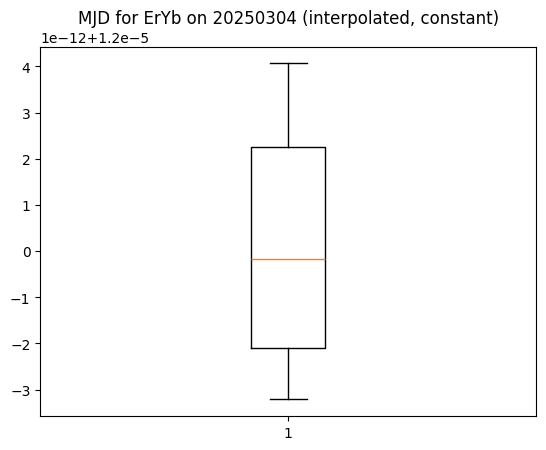

In [ ]:
##specify which interpolation method to view of ['time', 'linear', 'pad', 'nearest', 'cubic', 'kalman'] 
method_res = "kalman"  

if method_res == "kalman":
    starting_index = 30
else:
    starting_index = 1 #b/c first interpolated shift value can be NaN 
    
## sampling rates for interpolated data 
# print("Al min, first quartile, median, third quartile, max:\n", interp_Al_results[f"Al_shift_final_{method_res}"].index.to_series().diff().dt.total_seconds().quantile([0, 0.25, 0.50, 0.75, 1.0]))

# print("Yb min, first quartile, median, third quartile, max:\n", interp_Yb_results[f"Yb_shift_final_{method_res}"].index.to_series().diff().dt.total_seconds().quantile([0, 0.25, 0.50, 0.75, 1.0]))

# print("ErYb nuAl min, first quartile, median, thrid quartile, max:\n", np.percentile(np.diff(comb_chunk["MJD"].astype(float)), [0, 25, 50, 75, 85, 95, 97, 99, 100])*24*3600)
# float_comb = [float(y) for y in np.diff(comb_chunk["MJD"])]
# plt.boxplot(float_comb)
# plt.title(f"MJD for ErYb on {what_is_the_day} (interpolated, constant)")
# plt.show()

In [ ]:
## process results for analysis 
nuAl = [Decimal(i) for i in comb_chunk['nuAl']]
# nuSr = [Decimal(i) for i in comb_chunk['nuSr']]
nuYb = [Decimal(i) for i in comb_chunk['nuYb']]

shiftAl = [Decimal(i) for i in interp_Al_results[f"Al_shift_final_{method_res}"]]
# shiftSr = [Decimal(i) for i in interp_Sr_results[f"Sr_shift_final_{method_res}"]]
shiftYb = [Decimal(i) for i in interp_Yb_results[f"Yb_shift_final_{method_res}"]]

frequency_Al_ErYb = [((i + j) * total_correction_Al).iloc[0] for i, j in zip(nuAl[starting_index:], shiftAl[starting_index:])]
# frequency_Sr_ErYb = [((i + j) * total_correction_Sr).iloc[0] for i, j in zip(nuSr[starting_index:], shiftSr[starting_index:])]
frequency_Yb_ErYb = [((i + j) * total_correction_Yb).iloc[0] for i, j in zip(nuYb[starting_index:], shiftYb[starting_index:])]

# frequency_ratio_ErYb1 = [(i / j - AlSrRatio2020)/AlSrRatio2020 for i,j in zip(frequency_Al_ErYb, frequency_Sr_ErYb)]
# frequency_ratio_ErYb2 = [(i / j - YbSrRatio2020)/YbSrRatio2020 for i,j in zip(frequency_Yb_ErYb, frequency_Sr_ErYb)]
frequency_ratio_ErYb3 = [(i / j - AlYbRatio2020)/AlYbRatio2020 for i,j in zip(frequency_Al_ErYb, frequency_Yb_ErYb)]

## print summary statistics 
if day_irregular_index != None:
    print("Date: ", days_irregular[day_irregular_index], " Method: ", method_res, "\n")
else: 
    print("Date: ", days[day_index], " Method: ", method_res, "\n")
# print("Al+/Sr ratio offset from BACON paper", '{:0.5}'.format(np.nanmean(frequency_ratio_ErYb1)))
# print("Yb/Sr ratio offset from BACON paper", '{:0.5}'.format(np.nanmean(frequency_ratio_ErYb2)))
print("Al+/Yb ratio offset from BACON paper", '{:0.5}'.format(np.nanmean(frequency_ratio_ErYb3)), '\n')

# print("Al+/Sr ADEV with tau=", math.floor(len(clean_frequency_ratio_ErYb1)/3), ": ", '{:0.5}'.format(overlapping_avar_fn(clean_frequency_ratio_ErYb1, math.floor(len(clean_frequency_ratio_ErYb1)/3)).sqrt()))
# print("Yb/Sr ADEV with tau=", math.floor(len(clean_frequency_ratio_ErYb2)/3), ": ", '{:0.5}'.format(overlapping_avar_fn(clean_frequency_ratio_ErYb2, math.floor(len(clean_frequency_ratio_ErYb2)/3)).sqrt())) 
# print("Al+/Yb ADEV with tau=", math.floor(len(clean_frequency_ratio_ErYb3)/3), ": ", '{:0.5}'.format(overlapping_avar_fn(clean_frequency_ratio_ErYb3, math.floor(len(clean_frequency_ratio_ErYb3)/3)).sqrt()))

Date:  20250304  Method:  kalman 

Al+/Yb ratio offset from BACON paper -1.9569E-18 



[Decimal('9.134231661307180306049256397E-20')
 Decimal('9.134231661307180306049256397E-20')
 Decimal('2.333707532567752932349301159E-19')
 Decimal('3.908242220196148436011496183E-19')
 Decimal('7.030037700598353988543031901E-19')
 Decimal('9.729372682676458668777291364E-19')
 Decimal('1.363907249761268955752857307E-18')
 Decimal('1.735979321122405383838749721E-18')
 Decimal('2.060726830088579070855561548E-18')
 Decimal('2.363390999482221501962549596E-18')
 Decimal('2.542442653903671936767614817E-18')
 Decimal('2.760947786699429821178160525E-18')
 Decimal('3.064146725013021652978294754E-18')
 Decimal('3.354568185263221922171387482E-18')
 Decimal('3.733856972433982448961022297E-18')
 Decimal('4.149468827951983445507206021E-18')
 Decimal('4.978690596228349780113922015E-18')
 Decimal('6.149626236875752085999204210E-18')
 Decimal('8.304217808301204129051322216E-18')
 Decimal('1.094274470559393179748778406E-17')
 Decimal('1.249978279907747083281040342E-17')
 Decimal('1.1493933816694482226114

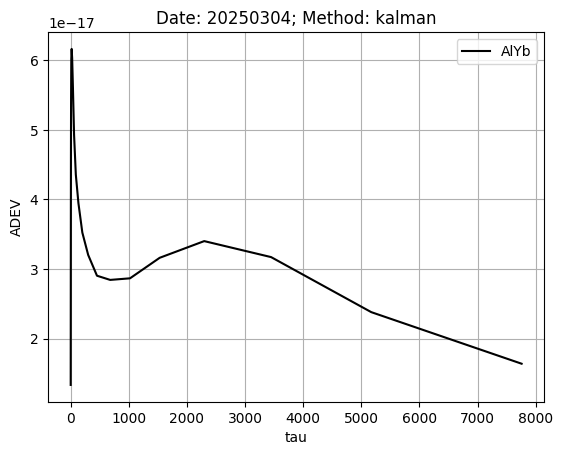

In [ ]:
## ADEV plot per day and method for all three ratios
tAlYb,adevAlYb,AlYberror = adev.adev(frequency_ratio_ErYb3, comb_chunk["MJD"], overlapping=True, tau='other', dx=1.5)

x = tAlYb
colors = { 
    # 'AlSr': 'blue',
    # 'YbSr': 'red',
    'AlYb': 'black'
}
adev_data = {
    # 'AlSr': [overlapping_avar_fn(clean_frequency_ratio_ErYb1, x) for x in tau_seq], 
    # 'YbSr': [overlapping_avar_fn(clean_frequency_ratio_ErYb2, x) for x in tau_seq],
    'AlYb': adevAlYb
}
adev_df = pd.DataFrame(adev_data)
# for col in adev_df.columns:
#     plt.plot(x, adev_df[col], label=col, color=colors.get(col, 'black'))
# if day_irregular_index != None:
#     plt.title('Date: ' + days_irregular[day_irregular_index] + '; Method: ' + method_res)
# else:
#     plt.title('Date: ' + days[day_index] + '; Method: ' + method_res)
# plt.ylabel('ADEV')
# plt.xlabel('tau')
# plt.legend()
# plt.grid(True)

# print(AlYberror)

In [143]:
##ERROR: can't do w/ type decimal 
## fit a white noise line excluding the points below 100 seconds
#whiteNoiseFitAlYb = adev.getWhiteNoiseFit(tAlYb, adevAlYb, AlYberror[1], tCutoff=100)

In [144]:
# ## Set day-ratio to investigate
# if day_irregular_index != None:
#     this_day = days_irregular[day_irregular_index]
# else: 
#     this_day = days[day_index]

# day_ratio_combo = [f"AlYb_on_day_{this_day}"]
# adev_data = {}

# for each_method in interp_methods:  
#     temp_df = interp_Al_results[f"Al_shift_final_{each_method}"]
    
#     ##necessary b/c kalman produces series, other methods produce data frame 
#     if isinstance(temp_df, pd.Series):
#         # If it's the Kalman Series, it likely IS the shift data already.
#         # We just slice the rows.
#         shift_series = temp_df.iloc[1:]
#     else:
#         # If it's a DataFrame (like 'time' or 'linear'), 
#         # we pick the 'shift' column and then slice the rows.
#         shift_series = temp_df['shift'].iloc[1:]

### Per day and ratio

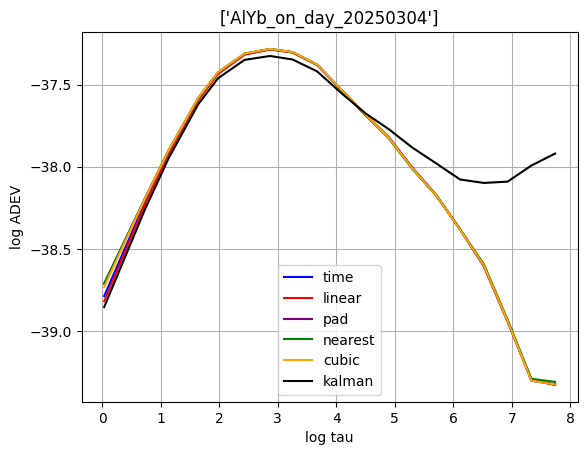

In [163]:
## Log-log ADEV with color coded methods; separate plot for each day-ratio combo
colors = { 
    'time': 'blue',
    'linear': 'red',
    'pad': 'purple',
    'nearest': 'green',
    'cubic': 'orange',
    'kalman': 'black'
}

## Set day-ratio to investigate
if day_irregular_index != None:
    this_day = days_irregular[day_irregular_index]
else: 
    this_day = days[day_index]

day_ratio_combo = [f"AlYb_on_day_{this_day}"]
adev_data = {}

for each_method in interp_methods:  
    starting_index = 30

    nuAl = [Decimal(i) for i in comb_chunk['nuAl'][starting_index:]]
    nuYb = [Decimal(i) for i in comb_chunk['nuYb'][starting_index:]]

    temp_Al_data = interp_Al_results[f"Al_shift_final_{each_method}"]
    temp_Yb_data = interp_Yb_results[f"Yb_shift_final_{each_method}"]

    ##necessary b/c kalman produces series, other methods produce data frame 
    if isinstance(temp_Al_data, pd.Series):
        shift_Al_series = temp_Al_data.iloc[starting_index:]
        shift_Yb_series = temp_Yb_data.iloc[starting_index:]
    else:
        shift_Al_series = temp_Al_data['shift'].iloc[starting_index:]
        shift_Yb_series = temp_Yb_data['shift'].iloc[starting_index:]
    
    shiftAl = [Decimal(i) for i in shift_Al_series]
    shiftYb = [Decimal(i) for i in shift_Yb_series]

    frequency_Al_ErYb = [((i + j) * total_correction_Al).iloc[0] for i, j in zip(nuAl, shiftAl)]
    frequency_Yb_ErYb = [((i + j) * total_correction_Yb).iloc[0] for i, j in zip(nuYb, shiftYb)]
    frequency_ratio_ErYb3 = [(i / j - AlYbRatio2020)/AlYbRatio2020 for i,j in zip(frequency_Al_ErYb, frequency_Yb_ErYb)]

    method_tau, method_adev, method_error = adev.adev(frequency_ratio_ErYb3, comb_chunk["MJD"], overlapping=True, tau='other', dx=1.5)

    ## create data frame
    tmp_df = pd.DataFrame({
        'tau': method_tau,
        'adev': method_adev,
        'error': method_error
    })

    method_key_name = f"{each_method}"
    adev_data[method_key_name] = tmp_df.copy()
    adev_data[method_key_name].name = method_key_name

adev_extracted = {}
for each_method in interp_methods:
    method_key_name = f"{each_method}"
    adev_extracted[method_key_name] = adev_data[method_key_name]['adev']

plot_adev_data = {
    'time': adev_extracted["time"],
    'linear': adev_extracted["linear"],
    'pad': adev_extracted["pad"],
    'nearest': adev_extracted["nearest"],
    'cubic': adev_extracted["cubic"],
    'kalman': adev_extracted["kalman"]
}
adev_df = pd.DataFrame(plot_adev_data)

## Note: must exclude last value of tau b/c is nan 
useable_len = len(adev_data["time"]["tau"]) - 2
tau_plot = [np.log(i) for i in adev_data["time"]["tau"][:useable_len]]
for col in adev_df.columns:
    adev_plot = adev_df[col][:useable_len].apply(lambda x: x.ln() if isinstance(x, Decimal) and x>0 else x)
    plt.plot(tau_plot, adev_plot, label=col, color=colors.get(col, 'black'))
plt.title(f"{day_ratio_combo}")
plt.ylabel('log ADEV')
plt.xlabel('log tau')
plt.legend()
plt.grid(True)